In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
train_data = pd.read_csv("../tmp/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test_data = pd.read_csv("../tmp/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

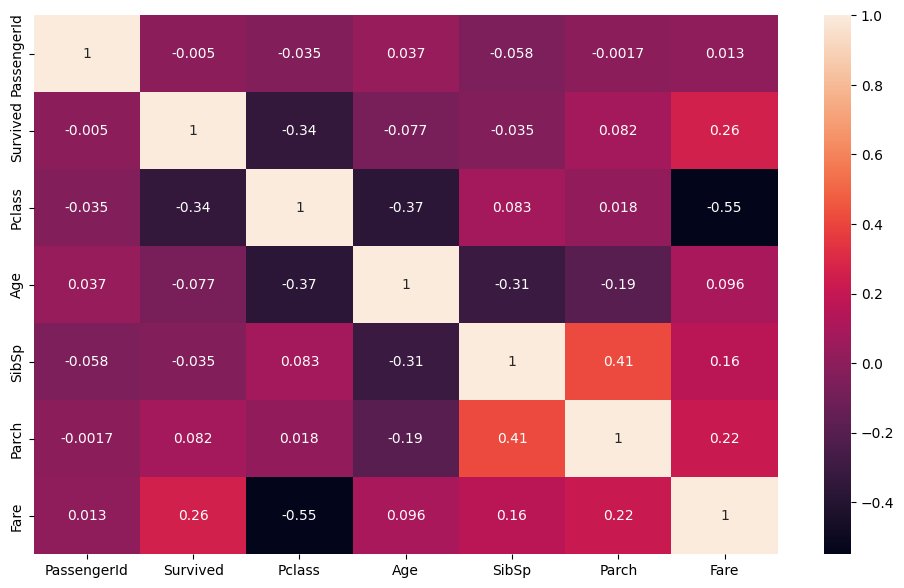

In [5]:
plt.figure(figsize=(12,7))
sns.heatmap(train_data.select_dtypes(include = ['number']).corr(), annot=True,)
plt.show()

# Version 3: Thay đổi việc xử lý missing value


<h1>Nhận xét thấy Age tương quan vừa với Pclass <br>
-> Ta sẽ dùng IterativeImputer hoặc KNN với Pclass và Age


In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.linear_model import BayesianRidge
# imp = IterativeImputer(max_iter=10, random_state=0)

# --- BƯỚC 1: LỌC CÁC CỘT CẦN DÙNG ĐỂ IMUPUTE ---
# Ta chỉ cần 'Age' (cột có thiếu) và 'Pclass' (cột để dự đoán)
# Pclass cần được chuyển thành kiểu số nguyên nếu chưa phải
X_impute = train_data[['Age', 'Pclass']].copy()

# --- BƯỚC 2: KHỞI TẠO VÀ CẤU HÌNH IMputer ---
# Sử dụng BayesianRidge làm estimator thường tốt hơn LinearRegression mặc định
# Bạn có thể giữ mặc định nếu muốn, nhưng đây là một tùy chọn nâng cao.
estimator = BayesianRidge()
# imputer_age = IterativeImputer(
#     estimator=estimator,
#     max_iter=10, 
#     random_state=42 # Đặt random_state để đảm bảo kết quả có thể tái lập
# )
imputer_age = KNNImputer(
    n_neighbors=5,  
    weights='uniform' 
)

# --- BƯỚC 3: FIT VÀ TRANSFORM DỮ LIỆU ---
# Fit: huấn luyện mô hình dự đoán trên dữ liệu có sẵn
# Transform: áp dụng mô hình để điền khuyết các giá trị NaN
X_imputed_array = imputer_age.fit_transform(X_impute)

# --- BƯỚC 4: CẬP NHẬT DATAFRAME GỐC ---
# Lấy cột Age đã được điền khuyết (cột đầu tiên của mảng kết quả)
train_data['Age_Imputed'] = X_imputed_array[:, 0]

# Chuyển đổi Age_Imputed sang số nguyên nếu bạn muốn tuổi là số nguyên
train_data['Age_Imputed'] = train_data['Age_Imputed'].round().astype(int)

# In kết quả
print("\nDataFrame sau khi điền khuyết:")
print(train_data[['Age', 'Pclass', 'Age_Imputed']].sample(5))


DataFrame sau khi điền khuyết:
       Age  Pclass  Age_Imputed
755   0.67       2            1
800  34.00       2           34
836  21.00       3           21
69   26.00       3           26
148  36.50       2           36


In [7]:
# train_data.drop(columns = ['Age'], inplace=True)

<h1>Xử lý missing value Embarked dễ dàng vì chỉ có vài dòng bị mất</h1>


In [8]:
# Gán giá trị mode (giá trị xuất hiện nhiều nhất) cho các giá trị missing của cột "Embarked" 
most_common_embarked = train_data['Embarked'].mode()[0]
train_data['Embarked'] = train_data['Embarked'].fillna(most_common_embarked)

<h1>Kiểm tra hết missing value chưa</h1>


In [9]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Age_Imputed      0
dtype: int64

<h1>Xử lý Cabin


In [10]:
# train_data["CabinKnown"] = train_data["Cabin"].notnull().astype(int)
# test_data["CabinKnown"] = test_data["Cabin"].notnull().astype(int)

In [11]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Age_Imputed      0
dtype: int64

<h1>Kiểm tra missing value bên tập test</h1>


In [12]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

<h1>Xử lý missing Age</h1>


In [13]:
X_impute = test_data[['Age', 'Pclass']].copy()
X_imputed_array = imputer_age.transform(X_impute)
test_data['Age_Imputed'] = X_imputed_array[:, 0]
test_data['Age_Imputed'] = test_data['Age_Imputed'].round().astype(int)

<h1>Xử lý missing fare dễ dàng vì chỉ mất 1 hàng</h1>


In [14]:
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())

<h1>Kiểm tra còn missing value không


In [15]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
Age_Imputed      0
dtype: int64

In [16]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
Age_Imputed      0
dtype: int64

In [17]:
print(train_data.isna().sum().sum())
print(test_data.isna().sum().sum())

864
413


<h1>Drop cột ticket


<h1>Xử lý name cho 2 tập bằng cách cắt ra từ đầu tiên sau dấu phẩy (Mr, Mrs, Dr,..)


In [18]:
# 1. Tạo name_title từ Name (làm trước khi drop)
train_data['name_title'] = train_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())
test_data['name_title'] = test_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())

# 2. Lấy top 5 title phổ biến nhất
top_5_titles = train_data['name_title'].value_counts().head(5).index.tolist()
print("Top 5 titles:", top_5_titles)

# 3. Gom tất cả title khác thành "Other"
train_data['name_title'] = train_data['name_title'].apply(lambda x: x if x in top_5_titles else 'Other')
test_data['name_title'] = test_data['name_title'].apply(lambda x: x if x in top_5_titles else 'Other')

# 4. Kiểm tra kết quả - CHỈ CÒN 6 CATEGORIES
print("\nAfter grouping - chỉ còn 6 categories:")
print(train_data['name_title'].value_counts())
print("\nTest data name_title counts:")
print(test_data['name_title'].value_counts())

train_data['name_title'] = train_data['name_title'].map({'Mr':0, 'Miss':1, 'Mrs':2, 'Master':3, 'Dr':4, 'Other': 5}).astype('int')
test_data['name_title'] = test_data['name_title'].map({'Mr':0, 'Miss':1, 'Mrs':2, 'Master':3, 'Dr':4, 'Other': 5}).astype('int')

# # 5. Sau đó mới drop column Name



Top 5 titles: ['Mr', 'Miss', 'Mrs', 'Master', 'Dr']

After grouping - chỉ còn 6 categories:
name_title
Mr        517
Miss      182
Mrs       125
Master     40
Other      20
Dr          7
Name: count, dtype: int64

Test data name_title counts:
name_title
Mr        240
Miss       78
Mrs        72
Master     21
Other       6
Dr          1
Name: count, dtype: int64


<h1>BoyOrFemale


In [19]:
def is_boy_row(row):
    # "boy" = male & (Age < 16 OR Title == 'Master')
    # age may be missing; Title helps
    return (row["Sex"] == "male") and ( (pd.notna(row["Age"]) and row["Age"] < 16) or (row.get("name_title","") == "Master"))

train_data["Boy"] = train_data.apply(is_boy_row, axis=1)
train_data["WomanOrBoy"] = (train_data["Sex"] == "female") | (train_data["Boy"])
test_data["Boy"] = test_data.apply(is_boy_row, axis=1)
test_data["WomanOrBoy"] = (test_data["Sex"] == "female") | (test_data["Boy"])

<h1>Mã hóa cột Sex thành 0 - 1


In [20]:
# Map male - 0, fale - 1
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

In [21]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Age_Imputed      0
name_title       0
Boy              0
WomanOrBoy       0
dtype: int64

In [22]:
train_data['Embarked'].value_counts

<bound method IndexOpsMixin.value_counts of 0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object>

In [23]:
pd.crosstab(index=train_data['Embarked'], columns=train_data['Survived'])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,219


In [24]:
train_data['Embarked'] = train_data['Embarked'].map({'C': 1, 'Q': 2, 'S': 3})
test_data['Embarked'] = test_data['Embarked'].map({'C': 1, 'Q': 2, 'S': 3})

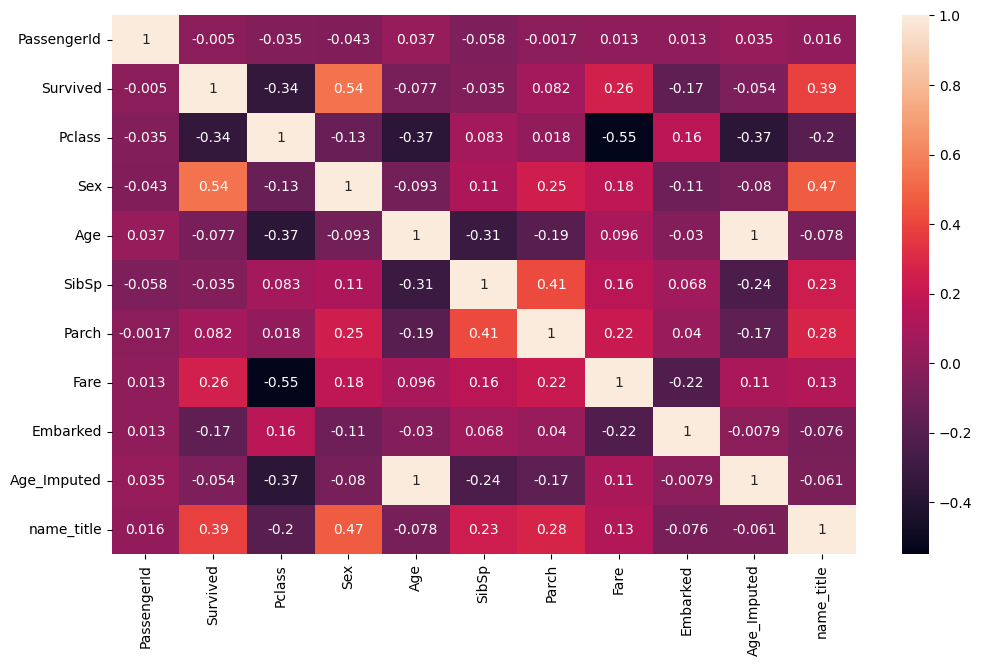

In [25]:
plt.figure(figsize=(12,7))
sns.heatmap(train_data.select_dtypes(include = ['number']).corr(), annot=True,)
plt.show()

In [26]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Age_Imputed      0
name_title       0
Boy              0
WomanOrBoy       0
dtype: int64

In [27]:
# train_data['Fare'] = np.log1p(train_data['Fare'].clip(lower=0))
# test_data['Fare'] = np.log1p(test_data['Fare'].clip(lower=0))

In [28]:
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1
train_data["FarePerPerson"] = (train_data["Fare"] / train_data["FamilySize"])
test_data["FarePerPerson"] = (test_data["Fare"] / test_data["FamilySize"])

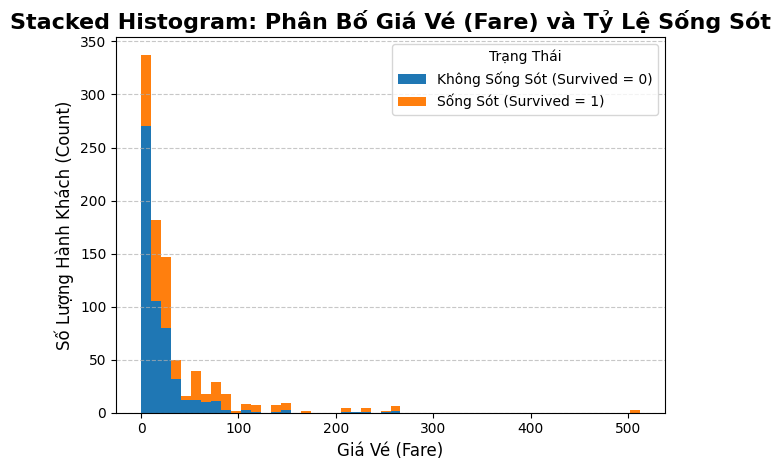

In [29]:
pd.crosstab(index=train_data['Fare'], columns = train_data['Survived'])
x_data1 = train_data[train_data['Survived'] == 0]['Fare']
x_data2 = train_data[train_data['Survived'] == 1]['Fare']
x_data = [x_data1, x_data2]
labels = ['Không Sống Sót (Survived = 0)', 'Sống Sót (Survived = 1)']
plt.hist(x_data, bins = 50, stacked=True, label=labels)
plt.title('Stacked Histogram: Phân Bố Giá Vé (Fare) và Tỷ Lệ Sống Sót', fontsize=16, fontweight='bold')
plt.xlabel('Giá Vé (Fare)', fontsize=12)
plt.ylabel('Số Lượng Hành Khách (Count)', fontsize=12)
plt.legend(loc='upper right', title="Trạng Thái")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
train_data['Fare'].value_counts()

Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 248, dtype: int64

In [31]:
# Cắt các giá trị theo khoảng và gắn labels
train_data['Fare_Cat'] = pd.cut(train_data['Fare'], bins=[-1000,40,80,200,1000], labels=['so_cheap', 'cheap', 'Medium', 'Expensive'])
test_data['Fare_Cat'] = pd.cut(test_data['Fare'], bins=[-1000,40,80,200,1000], labels=['so_cheap', 'cheap', 'Medium', 'Expensive']) 


# train_data['Fare_Cat'] = pd.qcut(train_data["Fare"], 4, duplicates="drop")
# train_data['Fare_Cat'] = train_data["Fare_Cat"].cat.codes
# test_data['Fare_Cat'] = pd.qcut(test_data["Fare"], 4, duplicates="drop")
# test_data['Fare_Cat'] = test_data["Fare_Cat"].cat.codes

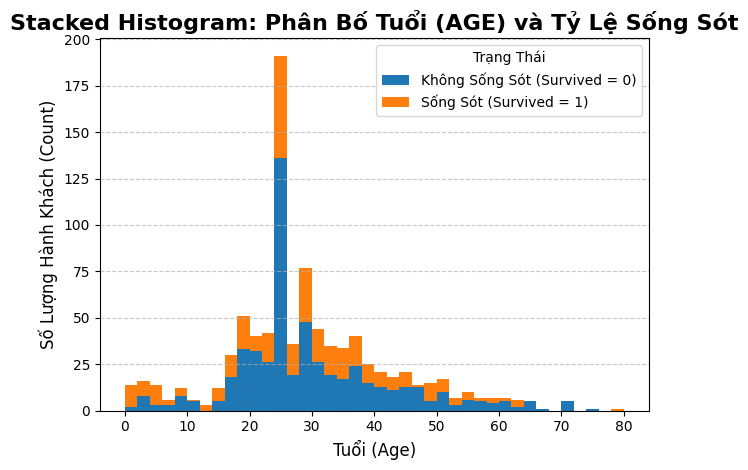

In [32]:
pd.crosstab(index=train_data['Age_Imputed'], columns = train_data['Survived'])
x_data1 = train_data[train_data['Survived'] == 0]['Age_Imputed']
x_data2 = train_data[train_data['Survived'] == 1]['Age_Imputed']
x_data = [x_data1, x_data2]
labels = ['Không Sống Sót (Survived = 0)', 'Sống Sót (Survived = 1)']
plt.hist(x_data, bins = 40, stacked=True, label=labels)
plt.title('Stacked Histogram: Phân Bố Tuổi (AGE) và Tỷ Lệ Sống Sót', fontsize=16, fontweight='bold')
plt.xlabel('Tuổi (Age)', fontsize=12)
plt.ylabel('Số Lượng Hành Khách (Count)', fontsize=12)
plt.legend(loc='upper right', title="Trạng Thái")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

0-12
12-22
22-34
34-46
46-64
64-100


In [33]:
# Cắt các giá trị theo khoảng và gắn labels
train_data['Age_Cat'] = pd.cut(train_data['Age_Imputed'], bins=[-100,12,22,34,46,64,100], labels=['babi', 'so_young', 'young', 'teenager', 'adult', 'old'])
test_data['Age_Cat'] = pd.cut(test_data['Age_Imputed'], bins=[-100,12,22,34,46,64,100], labels=['babi', 'so_young', 'young', 'teenager', 'adult', 'old']) 

# train_data['Age_Cat'] = pd.qcut(train_data["Age_Imputed"], 8, duplicates="drop")
# train_data['Age_Cat'] = train_data["Age_Cat"].cat.codes
# test_data['Age_Cat'] = pd.qcut(test_data["Age_Imputed"], 8, duplicates="drop")
# test_data['Age_Cat'] = test_data["Age_Cat"].cat.codes


train_data['Age_Cat'] = train_data['Age_Cat'].map({'babi': 1, 'so_young': 2, 'young': 3, 'teenager': 4, 'adult': 5, 'old': 6}).astype('int')
test_data['Age_Cat'] = test_data['Age_Cat'].map({'babi': 1, 'so_young': 2, 'young': 3, 'teenager': 4, 'adult': 5, 'old': 6}).astype('int') 

In [34]:
# aewerw

In [35]:
# d,;adlasdasd

In [36]:
train_data["Last_Name"] = train_data["Name"].str.split(",").str[0]
test_data["Last_Name"] = test_data["Name"].str.split(",").str[0]

In [37]:
DEFAULT_SURV = 0.5
fam_rules = {}
tmp = train_data.copy()
tmp["Last_Name"] = tmp["Name"].str.split(",").str[0]
tmp["Fare"] = tmp["Fare"].fillna(tmp["Fare"].median())
for (lname, fare), grp in tmp.groupby(["Last_Name", "Fare"], dropna=False):
    if len(grp) <= 1:
        continue
    smax = grp["Survived"].max()
    smin = grp["Survived"].min()
    if smax == 1:
        fam_rules[("LF", lname, fare)] = 1.0
    elif smin == 0:
        fam_rules[("LF", lname, fare)] = 0.0

In [38]:
# Quy tắc theo Ticket trong TRAIN
for ticket, grp in tmp.groupby("Ticket", dropna=False):
    if len(grp) <= 1:
        continue
    smax = grp["Survived"].max()
    smin = grp["Survived"].min()
    if smax == 1:
        fam_rules[("T", ticket)] = 1.0
    elif smin == 0:
        fam_rules[("T", ticket)] = 0.0

In [39]:
train_data["Fare"] = train_data["Fare"].astype(float)
train_data["Fare"] = train_data.groupby("Pclass")["Fare"].transform(lambda s: s.fillna(s.median()))
test_data["Fare"] = test_data["Fare"].astype(float)
test_data["Fare"] = test_data.groupby("Pclass")["Fare"].transform(lambda s: s.fillna(s.median()))

In [40]:
def infer_family_survival(row):
    # Ưu tiên quy tắc theo Last_Name + Fare
    key1 = ("LF", row["Last_Name"], row["Fare"])
    if key1 in fam_rules:
        return fam_rules[key1]
    # Sau đó đến Ticket
    key2 = ("T", row["Ticket"])
    if key2 in fam_rules:
        return fam_rules[key2]
    return DEFAULT_SURV

train_data["Family_Survival"] = train_data.apply(infer_family_survival, axis=1)
test_data["Family_Survival"] = test_data.apply(infer_family_survival, axis=1)

In [41]:
train_data['Family_Survival'].value_counts()

Family_Survival
0.5    516
1.0    236
0.0    139
Name: count, dtype: int64

In [42]:
train_data.isna().sum()

PassengerId          0
Survived             0
Pclass               0
Name                 0
Sex                  0
Age                177
SibSp                0
Parch                0
Ticket               0
Fare                 0
Cabin              687
Embarked             0
Age_Imputed          0
name_title           0
Boy                  0
WomanOrBoy           0
FamilySize           0
FarePerPerson        0
Fare_Cat             0
Age_Cat              0
Last_Name            0
Family_Survival      0
dtype: int64

<h1>Xử lý Cabin


In [43]:
def extract_deck(cabin: str) -> str:
    if pd.isna(cabin) or not str(cabin).strip():
        return "DECK_NA"
    first = str(cabin).split()[0]
    letter = first[0].upper()
    return f"DECK_{letter}" if letter in list("ABCDEFGT") else "DECK_OTHER"

In [44]:
# train_data["Deck"] = train_data["Cabin"].apply(extract_deck)
# test_data["Deck"] = test_data["Cabin"].apply(extract_deck)

<h1>Xử lý ticket


In [45]:
def cleanTicket(ticket):  
    ticket = ticket.replace('.','')  
    ticket = ticket.replace('/','')  
    ticket = ticket.split()  
    ticket = map(lambda t: t.strip(), ticket)  
    ticket = list(filter(lambda t: not t.isdigit(), ticket))  
    if len(ticket) > 0:  
      return ticket[0]  
    else:  
      return 'XXX'  

In [46]:
# train_data["Ticket_Cat"] = train_data["Ticket"].map(cleanTicket)
# test_data["Ticket_Cat"] = test_data["Ticket"].map(cleanTicket)

In [47]:
# print(train_data['Ticket_Cat'].value_counts)

In [48]:
# train_data.drop(columns=['Ticket_Cat'], inplace=True)
# test_data.drop(columns=['Ticket_Cat'], inplace=True)

<h1>Dummies để tăng hiệu suất train


In [49]:
dummies_col = ['name_title', 'Fare_Cat', 'Age_Cat']
for col in dummies_col:
    train_data = pd.get_dummies(train_data, columns=[col], drop_first=True)
    test_data = pd.get_dummies(test_data, columns=[col], drop_first=True)

<h1>Không drop fare mà xử lý log1np


In [50]:
# train_data['Fare'] = train_data['Fare'].apply(np.log1p)
# test_data['Fare'] = test_data['Fare'].apply(np.log1p)
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# for col in ['Fare', 'Age_Imputed']:
#     train_data[col] = scaler.fit_transform(train_data[[col]])
#     test_data[col] = scaler.transform(test_data[[col]])

In [51]:
train_data['IsAlone'] = (train_data['FamilySize'] == 1).astype(int)
test_data['IsAlone'] = (test_data['FamilySize'] == 1).astype(int)

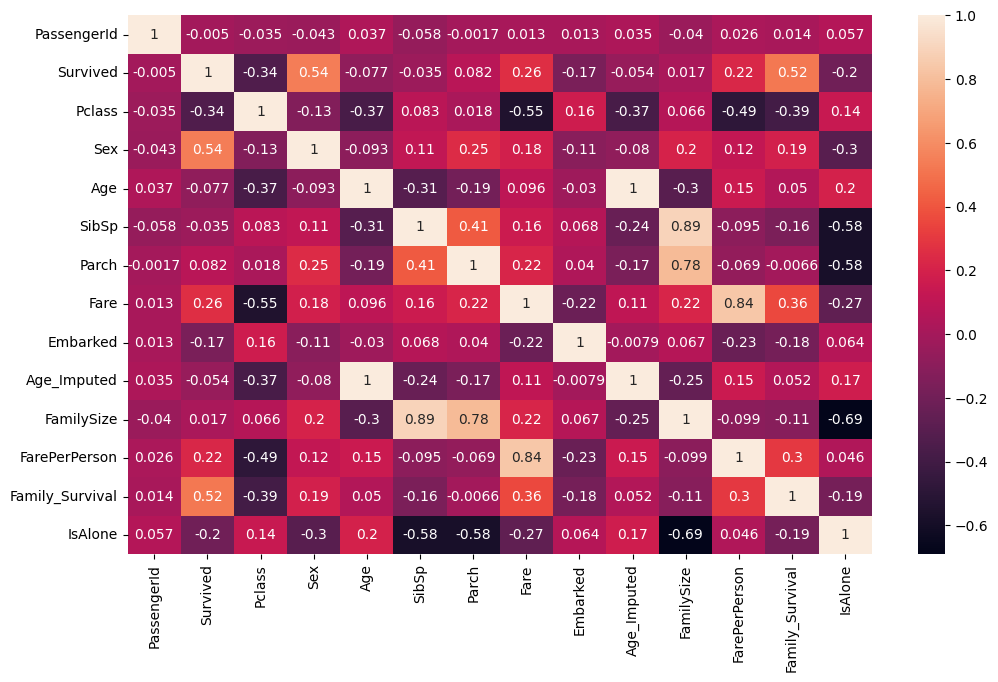

In [52]:
plt.figure(figsize=(12,7))
sns.heatmap(train_data.select_dtypes(include = ['number']).corr(), annot=True,)
plt.show()

In [53]:
train_data.isna().sum()

PassengerId             0
Survived                0
Pclass                  0
Name                    0
Sex                     0
Age                   177
SibSp                   0
Parch                   0
Ticket                  0
Fare                    0
Cabin                 687
Embarked                0
Age_Imputed             0
Boy                     0
WomanOrBoy              0
FamilySize              0
FarePerPerson           0
Last_Name               0
Family_Survival         0
name_title_1            0
name_title_2            0
name_title_3            0
name_title_4            0
name_title_5            0
Fare_Cat_cheap          0
Fare_Cat_Medium         0
Fare_Cat_Expensive      0
Age_Cat_2               0
Age_Cat_3               0
Age_Cat_4               0
Age_Cat_5               0
Age_Cat_6               0
IsAlone                 0
dtype: int64

<h1>Drop data


In [54]:
drop_cols = ['PassengerId', 'Cabin', 'Ticket', 'Name', 'Age', 'Fare', 'Last_Name', 'Age_Imputed', 'FarePerPerson']
for col in drop_cols:
    train_data.drop(columns=[col], inplace=True)
    test_data.drop(columns=[col], inplace=True)

In [55]:
train_data.isna().sum()

Survived              0
Pclass                0
Sex                   0
SibSp                 0
Parch                 0
Embarked              0
Boy                   0
WomanOrBoy            0
FamilySize            0
Family_Survival       0
name_title_1          0
name_title_2          0
name_title_3          0
name_title_4          0
name_title_5          0
Fare_Cat_cheap        0
Fare_Cat_Medium       0
Fare_Cat_Expensive    0
Age_Cat_2             0
Age_Cat_3             0
Age_Cat_4             0
Age_Cat_5             0
Age_Cat_6             0
IsAlone               0
dtype: int64

In [56]:
sum([1 for _ in train_data.columns])

24

In [57]:
dfdfđ

NameError: name 'dfdfđ' is not defined

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
for col in test_data.columns:
    train_data[col] = scaler.fit_transform(train_data[[col]])
    test_data[col] = scaler.transform(test_data[[col]])

In [ ]:
from sklearn.model_selection import train_test_split

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
train_data.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

param_grid = {
    "n_neighbors": [6,7,8,9,10,11,12,14,16,18,20,22],
    "weights": ["uniform", "distance"],
    "leaf_size": list(range(1, 50, 5)),
    "algorithm": ["auto"],   # có thể thêm 'ball_tree','kd_tree' nếu muốn thử
    "p": [1, 2],             # Manhattan / Euclidean
}

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
    # 'KNN': grid
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)

    print(f"{name} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC AUC:  {roc_auc:.4f}")
    print("-" * 30)

Logistic Regression Results:
  Accuracy: 0.8380
  F1 Score: 0.7914
  ROC AUC:  0.9072
------------------------------
Random Forest Results:
  Accuracy: 0.7989
  F1 Score: 0.7313
  ROC AUC:  0.8764
------------------------------
XGBoost Results:
  Accuracy: 0.8045
  F1 Score: 0.7482
  ROC AUC:  0.8480
------------------------------


In [ ]:
# import pandas as pd
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, VotingClassifier
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
# from sklearn.model_selection import train_test_split
# import numpy as np

# clf1 = LogisticRegression(random_state=42, max_iter=1000)
# clf2 = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200)
# clf3 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)

# models = {
#     'Logistic Regression': clf1,
#     'Random Forest': clf2,
#     'XGBoost': clf3
# }


# # --- 3. HUẤN LUYỆN VÀ ĐÁNH GIÁ CÁC MÔ HÌNH RIÊNG LẺ ---
# results = {}
# for name, model in models.items():
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_val)
#     y_prob = model.predict_proba(X_val)[:, 1]

#     acc = accuracy_score(y_val, y_pred)
#     f1 = f1_score(y_val, y_pred)
#     roc_auc = roc_auc_score(y_val, y_prob)
    
#     results[name] = {'Accuracy': acc, 'F1 Score': f1, 'ROC AUC': roc_auc}

# # --- 4. TẠO VÀ HUẤN LUYỆN VOTING CLASSIFIER (Soft Voting) ---

# # Tạo danh sách các mô hình (tên, instance)
# estimators = [
#     ('lr', clf1),
#     ('rf', clf2),
#     ('xgb', clf3)
# ]

# # Khởi tạo VotingClassifier với Soft Voting
# # voting='soft' đòi hỏi các mô hình phải hỗ trợ predict_proba (tất cả 3 mô hình này đều hỗ trợ)
# # Weights có thể được thêm vào nếu bạn muốn mô hình nào đó quan trọng hơn
# voting_clf = VotingClassifier(
#     estimators=estimators, 
#     voting='soft', 
#     n_jobs=-1 # Sử dụng tất cả các core CPU
# )

# # Huấn luyện Voting Classifier
# # Nó sẽ huấn luyện lại tất cả các mô hình thành phần trên tập X_train
# print("Bắt đầu huấn luyện Ensemble Voting Classifier...")
# voting_clf.fit(X_train, y_train)
# print("Huấn luyện Voting Classifier hoàn tất.")
# print("-" * 30)

# # --- 5. ĐÁNH GIÁ VOTING CLASSIFIER ---
# y_pred_voting = voting_clf.predict(X_val)
# y_prob_voting = voting_clf.predict_proba(X_val)[:, 1]

# acc_v = accuracy_score(y_val, y_pred_voting)
# f1_v = f1_score(y_val, y_pred_voting)
# roc_auc_v = roc_auc_score(y_val, y_prob_voting)

# results['Ensemble Voting (Soft)'] = {'Accuracy': acc_v, 'F1 Score': f1_v, 'ROC AUC': roc_auc_v}

# print("Ensemble Voting (Soft) Results:")
# print(f"  Accuracy: {acc_v:.4f}")
# print(f"  F1 Score: {f1_v:.4f}")
# print(f"  ROC AUC:  {roc_auc_v:.4f}")
# print("-" * 30)

# # --- TỔNG HỢP VÀ SO SÁNH KẾT QUẢ ---
# results_df = pd.DataFrame(results).T
# print("Bảng so sánh kết quả cuối cùng:")
# print(results_df.sort_values(by='ROC AUC', ascending=False).round(4))


In [ ]:
best_model = LogisticRegression(random_state=42, max_iter=1000)
# best_model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200)
# best_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
# best_model = voting_clf
best_model.fit(X_train, y_train)

y_val_pred = best_model.predict(X_val)

print("Actual values (first 5):")
print(y_val.head())

print("\nPredicted values (first 5):")
print(pd.Series(y_val_pred).head())

Actual values (first 5):
565    0
160    0
553    1
860    0
241    1
Name: Survived, dtype: int64

Predicted values (first 5):
0    0
1    0
2    0
3    0
4    1
dtype: int64


In [ ]:
# Orijinal test csv'sini tekrar yükle (PassengerId için)
test_data_orig = pd.read_csv("/kaggle/input/titanic/test.csv")

# 1. Lấy danh sách tên cột từ tập huấn luyện (X_train)
# Đây là danh sách các cột mà mô hình của bạn đã được fit (học).
# LƯU Ý: Phải sử dụng X_train (hoặc biến chứa các features đã dùng để fit mô hình)
feature_cols_at_fit = X_train.columns

# 2. Đồng bộ hóa tập test_data
# Đảm bảo test_data có số lượng cột, tên cột và thứ tự cột giống hệt X_train.
# Các cột thiếu (ví dụ: 'Cabin_Imputed_7.0') sẽ được thêm vào với giá trị 0.
test_data_aligned = test_data.reindex(columns=feature_cols_at_fit, fill_value=0)

# best_model ile test verisi üzerinde tahmin yap
test_preds = best_model.predict(test_data_aligned)

# Submission dataframe'i oluştur
submission = pd.DataFrame({
    "PassengerId": test_data_orig["PassengerId"],
    "Survived": test_preds
})

# CSV olarak kaydet (kaggle ortamında)
submission.to_csv("submission.csv", index=False)

print("Submission file 'submission.csv' created.")

Submission file 'submission.csv' created.
